# Medium Access Control simulation (exponential backoff)


## 1) Objectif du projet
Modéliser N stations qui génèrent des paquets avec des arrivées de Poisson de paramètre $\lambda$.
Chaque station possède une file bornée de capacité $K$.
Une émission dure 1 unité de temps.
Si plusieurs stations émettent en même temps, collision: aucune transmission n'aboutit.
Après collision, la station attend un backoff exponentiel avant de réessayer.

### Réutilisation directe des TD
- TD2: simulation à événements discrets avec un échéancier (tas min)
- TD2/TD5: génération de durées exponentielles
- TD5: moyenne, variance et intervalle de confiance pour les études Monte Carlo

### Mesures produites
- Débit: nombre de succès divisé par le temps
- Taille moyenne de la file
- Taux de perte: paquets rejetés / paquets arrivés

In [1]:
# Imports bases sur les TD
import math
import random as rd
import heapq
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional

import numpy as np
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8")

# --- Fonctions utilitaires reprises des TD ---
def duree_exp(p: float) -> float:
    """TD2/TD5: genere une duree exponentielle de parametre p."""
    return np.random.exponential(1 / p) if p > 0 else float("inf")

def moyenne(data: List[float]) -> float:
    return float(sum(data) / len(data)) if data else 0.0

def variance(data: List[float]) -> float:
    if len(data) < 2:
        return 0.0
    m = moyenne(data)
    return float(sum((x - m) ** 2 for x in data) / (len(data) - 1))

def intervalle_confiance_95(data: List[float]) -> Tuple[float, float]:
    """Approximation normale 95%, comme dans TD5."""
    if not data:
        return 0.0, 0.0
    m = moyenne(data)
    v = variance(data)
    delta = 1.96 * math.sqrt(v / len(data)) if len(data) > 1 else 0.0
    return m - delta, m + delta

In [2]:
from heapq import heappush, heappop

@dataclass
class Station:
    # file locale de la station
    queue: int = 0
    # niveau de backoff exponentiel
    state: int = 1
    # True si la station attend la fin du backoff
    waiting_backoff: bool = False

def simulate_once(
    N: int,
    K: int,
    lam: float,
    tau: float,
    t_max: float,
    sample_dt: float = 1.0,
    max_backoff_exp: int = 10,
    seed: Optional[int] = None,
    np_seed: Optional[int] = None,
) -> Dict[str, object]:
    """
    Simulateur a evenements discrets (style TD2) pour un protocole MAC avec collisions
    et backoff exponentiel binaire.
    """
    if seed is not None:
        rd.seed(seed)
    if np_seed is None and seed is not None:
        np_seed = seed
    if np_seed is not None:
        np.random.seed(np_seed)

    stations: List[Station] = [Station() for _ in range(N)]
    echeancier: List[Tuple[float, int, str, Optional[int]]] = []
    # transmissions en cours: idx station -> infos de transmission
    active_txs: Dict[int, Dict[str, object]] = {}

    # stats globales
    total_queue = 0
    area_queue = 0.0
    last_time = 0.0
    successes = 0
    arrivals = 0
    drops = 0

    # donnees pour graphiques
    compteur_evt = 0
    next_sample = sample_dt
    times: List[float] = []
    throughput: List[float] = []
    mean_queue: List[float] = []
    loss_rate: List[float] = []

    def schedule(time: float, typ: str, idx: Optional[int] = None) -> None:
        nonlocal compteur_evt
        heappush(echeancier, (time, compteur_evt, typ, idx))
        compteur_evt += 1

    def attempt_transmit(idx: int, now: float) -> None:
        nonlocal total_queue
        if idx in active_txs:
            return
        st = stations[idx]
        if st.queue <= 0 or st.waiting_backoff:
            return

        # un paquet quitte la file locale et part en emission (duree fixe = 1)
        st.queue -= 1
        total_queue -= 1
        active_txs[idx] = {"end": now + 1.0, "collided": False}
        schedule(now + 1.0, "tx_end", idx)

        # si plusieurs emissions se chevauchent, collision pour toutes
        if len(active_txs) > 1:
            for tx in active_txs.values():
                tx["collided"] = True

    # initialisation des premieres arrivees (Poisson)
    for i in range(N):
        schedule(duree_exp(lam), "arrival", i)

    while echeancier and echeancier[0][0] <= t_max:
        t_evt, _, typ, idx = heappop(echeancier)

        # echantillonnage periodique des mesures
        while next_sample <= t_evt and next_sample <= t_max:
            area_queue += total_queue * (next_sample - last_time)
            last_time = next_sample

            times.append(next_sample)
            throughput.append(successes / next_sample if next_sample > 0 else 0.0)
            mean_queue.append(area_queue / next_sample if next_sample > 0 else 0.0)
            loss_rate.append(drops / arrivals if arrivals > 0 else 0.0)

            next_sample += sample_dt

        area_queue += total_queue * (t_evt - last_time)
        last_time = t_evt

        if typ == "arrival" and idx is not None:
            arrivals += 1
            st = stations[idx]

            if st.queue < K:
                st.queue += 1
                total_queue += 1
                if not st.waiting_backoff and idx not in active_txs:
                    attempt_transmit(idx, t_evt)
            else:
                drops += 1

            # prochaine arrivee de cette station
            schedule(t_evt + duree_exp(lam), "arrival", idx)

        elif typ == "backoff_expire" and idx is not None:
            st = stations[idx]
            st.waiting_backoff = False
            attempt_transmit(idx, t_evt)

        elif typ == "tx_end" and idx is not None:
            tx = active_txs.pop(idx, None)
            if tx is None:
                continue

            st = stations[idx]
            if tx["collided"]:
                # collision: on augmente le niveau de backoff
                st.state = min(st.state + 1, max_backoff_exp)
                st.waiting_backoff = False
                if st.queue > 0:
                    # attente moyenne 2^(i-1) * tau, donc taux = 1 / attente_moyenne
                    attente_moy = (2 ** (st.state - 1)) * tau
                    delay = duree_exp(1.0 / attente_moy)
                    st.waiting_backoff = True
                    schedule(t_evt + delay, "backoff_expire", idx)
            else:
                # succes: retour au niveau de base
                successes += 1
                st.state = 1
                st.waiting_backoff = False
                if st.queue > 0:
                    attempt_transmit(idx, t_evt)

    # complete les points d'echantillonnage restants jusqu'a t_max
    while next_sample <= t_max:
        area_queue += total_queue * (next_sample - last_time)
        last_time = next_sample

        times.append(next_sample)
        throughput.append(successes / next_sample if next_sample > 0 else 0.0)
        mean_queue.append(area_queue / next_sample if next_sample > 0 else 0.0)
        loss_rate.append(drops / arrivals if arrivals > 0 else 0.0)

        next_sample += sample_dt

    return {
        "times": times,
        "throughput": throughput,
        "mean_queue": mean_queue,
        "loss_rate": loss_rate,
        "throughput_final": successes / t_max if t_max > 0 else 0.0,
        "successes": successes,
        "arrivals": arrivals,
        "drops": drops,
    }

def sweep_lambda(
    lambdas: List[float],
    N: int,
    K: int,
    tau: float,
    t_max: float,
    runs: int = 10,
    seed: int = 123,
 ) -> List[Tuple[float, float, float, float]]:
    """Retourne (lambda, moyenne debit, borne_inf_IC95, borne_sup_IC95)."""
    out: List[Tuple[float, float, float, float]] = []
    for lam in lambdas:
        values: List[float] = []
        for r in range(runs):
            res = simulate_once(
                N=N, K=K, lam=lam, tau=tau, t_max=t_max,
                seed=seed + r + int(1000 * lam),
            )
            values.append(float(res["throughput_final"]))

        m = moyenne(values)
        ci_low, ci_high = intervalle_confiance_95(values)
        out.append((lam, m, ci_low, ci_high))
    return out

def sweep_N(
    N_values: List[int],
    K: int,
    lam: float,
    tau: float,
    t_max: float,
    runs: int = 10,
    seed: int = 321,
 ) -> List[Tuple[int, float, float, float]]:
    """Retourne (N, moyenne debit, borne_inf_IC95, borne_sup_IC95)."""
    out: List[Tuple[int, float, float, float]] = []
    for i, N in enumerate(N_values):
        values: List[float] = []
        for r in range(runs):
            res = simulate_once(
                N=N, K=K, lam=lam, tau=tau, t_max=t_max,
                seed=seed + 100 * i + r,
            )
            values.append(float(res["throughput_final"]))

        m = moyenne(values)
        ci_low, ci_high = intervalle_confiance_95(values)
        out.append((N, m, ci_low, ci_high))
    return out

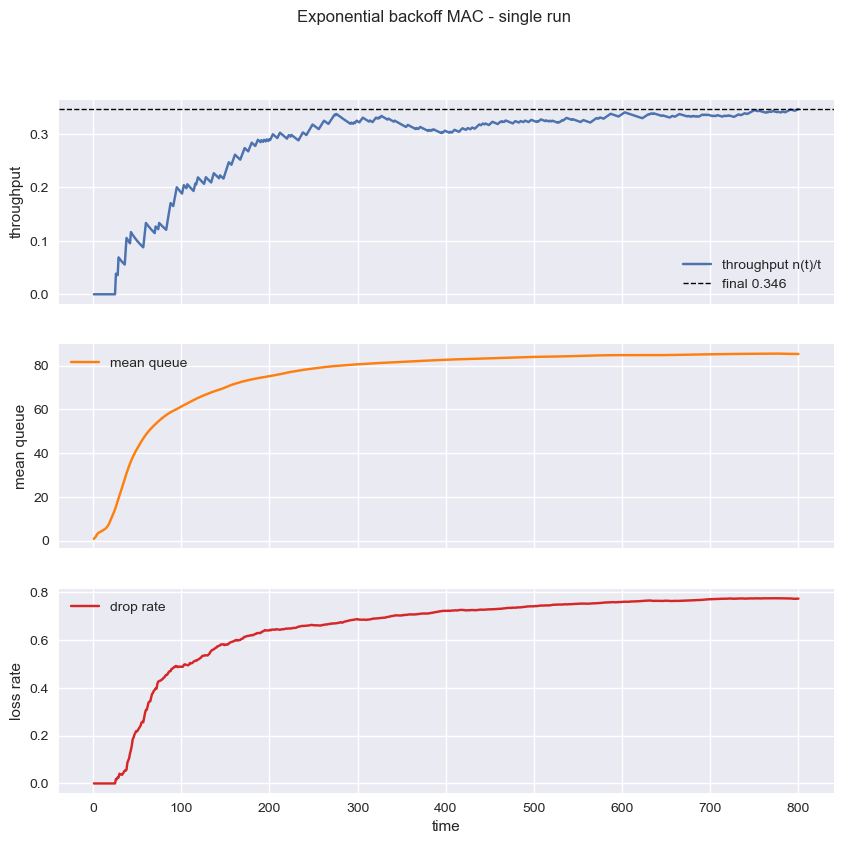

Final throughput=0.3463, successes=277, arrivals=3209, drops=2478


In [3]:
# Single-run demo and time evolution plots
BASE = dict(N=10, K=10, lam=0.4, tau=0.5, t_max=800, sample_dt=1.0, max_backoff_exp=10, seed=42)
sim = simulate_once(**BASE)

fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True)
axes[0].plot(sim['times'], sim['throughput'], label='throughput n(t)/t')
axes[0].axhline(sim['throughput_final'], color='k', ls='--', lw=1, label=f"final {sim['throughput_final']:.3f}")
axes[0].set_ylabel('throughput')
axes[0].legend()
axes[1].plot(sim['times'], sim['mean_queue'], color='tab:orange', label='mean queue')
axes[1].set_ylabel('mean queue')
axes[1].legend()
axes[2].plot(sim['times'], sim['loss_rate'], color='tab:red', label='drop rate')
axes[2].set_ylabel('loss rate')
axes[2].set_xlabel('time')
axes[2].legend()
fig.suptitle('Exponential backoff MAC - single run')
plt.show()
print(f"Final throughput={sim['throughput_final']:.4f}, successes={sim['successes']}, arrivals={sim['arrivals']}, drops={sim['drops']}")

## 2) Étude paramétrique (Monte Carlo)
Dans cette partie, on réalise plusieurs simulations indépendantes pour:
- faire varier $\lambda$ et observer l'évolution du débit moyen
- faire varier $N$ et observer la saturation du canal
- comparer l'effet du paramètre de backoff $\tau$

Chaque point affiché sera la moyenne de plusieurs runs avec son intervalle de confiance à 95%.

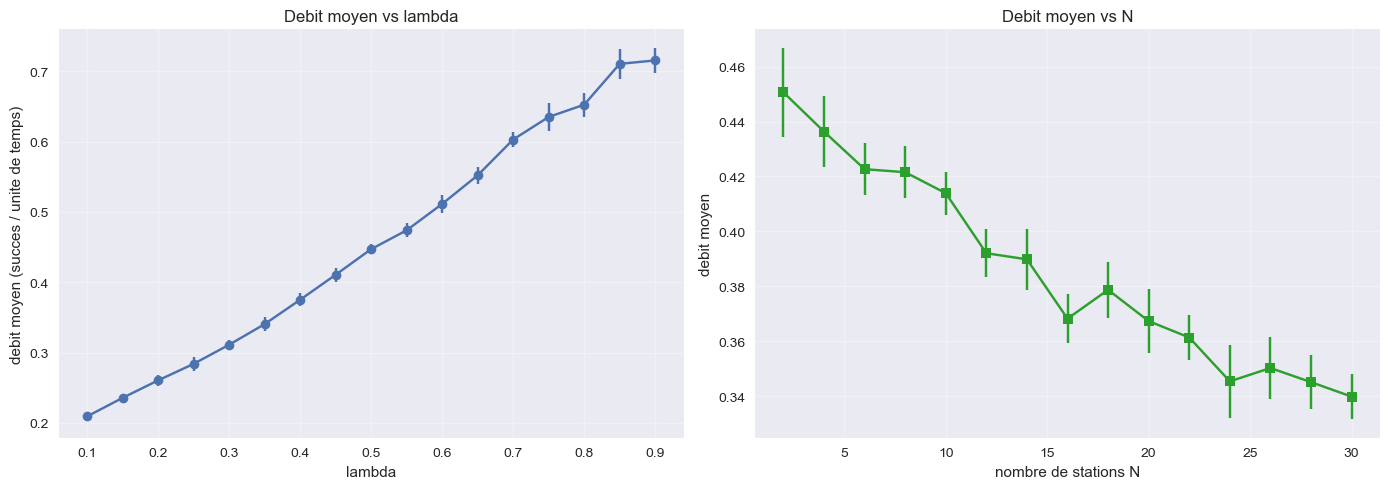


Resume impact de tau (N=12, lambda=0.55):
tau=0.20 -> debit moyen=0.4185, IC95=[0.4062, 0.4307]
tau=0.50 -> debit moyen=0.4676, IC95=[0.4585, 0.4768]
tau=1.00 -> debit moyen=0.4713, IC95=[0.4569, 0.4856]
tau=2.00 -> debit moyen=0.4684, IC95=[0.4493, 0.4875]

Lecture rapide:
- Quand lambda augmente, le debit monte puis se degrade si les collisions dominent.
- Quand N augmente, le canal sature et le debit par station chute.
- Tau trop petit peut augmenter les collisions; trop grand augmente l'attente.


In [4]:
# Etude 1: debit moyen en fonction de lambda
N = 10
K = 10
tau = 0.5
t_max = 1200
runs = 12

lambdas = [0.05 * i for i in range(2, 19)]  # 0.1 a 0.9
res_lam = sweep_lambda(lambdas, N=N, K=K, tau=tau, t_max=t_max, runs=runs, seed=2026)

x_l = [x[0] for x in res_lam]
y_l = [x[1] for x in res_lam]
lo_l = [x[2] for x in res_lam]
hi_l = [x[3] for x in res_lam]
err_l = [max(y - lo, hi - y) for y, lo, hi in zip(y_l, lo_l, hi_l)]

# Etude 2: debit moyen en fonction du nombre de stations
N_values = list(range(2, 32, 2))
res_N = sweep_N(N_values, K=K, lam=0.45, tau=tau, t_max=t_max, runs=runs, seed=3030)

x_n = [x[0] for x in res_N]
y_n = [x[1] for x in res_N]
lo_n = [x[2] for x in res_N]
hi_n = [x[3] for x in res_N]
err_n = [max(y - lo, hi - y) for y, lo, hi in zip(y_n, lo_n, hi_n)]

# Etude 3: impact du backoff tau pour une charge fixee
tau_values = [0.2, 0.5, 1.0, 2.0]
stats_tau = []
for tau_test in tau_values:
    vals = []
    for r in range(runs):
        sim_tau = simulate_once(
            N=12, K=10, lam=0.55, tau=tau_test, t_max=t_max,
            seed=4040 + r + int(100 * tau_test),
        )
        vals.append(float(sim_tau["throughput_final"]))
    m_tau = moyenne(vals)
    ci_tau = intervalle_confiance_95(vals)
    stats_tau.append((tau_test, m_tau, ci_tau[0], ci_tau[1]))

# Affichages
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].errorbar(x_l, y_l, yerr=err_l, fmt='o-', capsize=4)
axes[0].set_title("Debit moyen vs lambda")
axes[0].set_xlabel("lambda")
axes[0].set_ylabel("debit moyen (succes / unite de temps)")
axes[0].grid(alpha=0.3)

axes[1].errorbar(x_n, y_n, yerr=err_n, fmt='s-', capsize=4, color='tab:green')
axes[1].set_title("Debit moyen vs N")
axes[1].set_xlabel("nombre de stations N")
axes[1].set_ylabel("debit moyen")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\nResume impact de tau (N=12, lambda=0.55):")
for tau_test, m_tau, lo_tau, hi_tau in stats_tau:
    print(f"tau={tau_test:.2f} -> debit moyen={m_tau:.4f}, IC95=[{lo_tau:.4f}, {hi_tau:.4f}]")

print("\nLecture rapide:")
print("- Quand lambda augmente, le debit monte puis se degrade si les collisions dominent.")
print("- Quand N augmente, le canal sature et le debit par station chute.")
print("- Tau trop petit peut augmenter les collisions; trop grand augmente l'attente.")